# Boundary-Update Impairment vs Global Drift Reduction
## Targeted CMR Simulations

Can **localized** and **global** changes in encoding drift
$\beta_{enc}$ produce distinguishable behavioural signatures
in recall organisation?

We test two hypotheses with a 32-item list and three mid-list
boundaries (positions 9, 17, 25 → four 8-item segments):

| Hypothesis | Manipulation | What varies | What stays fixed |
|---|---|---|---|
| **H1 — Boundary impairment** | Reduce the drift boost $\Delta$ at each boundary | $\Delta \in \{0.4, 0.3, 0.2, 0.1, 0.0\}$ | Non-boundary drift = 0.6 |
| **H2 — Global drift reduction** | Lower *all* drifts uniformly | Non-boundary ∈ {0.6, 0.4, 0.2}; boundary ∈ {1.0, 0.8, 0.4} | Boundary boost pattern preserved |

---

## Empirical motivation

The PTSD event-segmentation literature (Pitts et al., 2022;
Eisenberg et al., 2023; Granger et al., 2025) shows that
trauma-exposed individuals have impaired boundary detection and
weaker context-update signals at event transitions.  A separate
line of work (Rougemont-Bücking et al., 2011; Letkiewicz,
Cochran & Cisler, 2022) suggests globally reduced context
integration.  The key question is whether these two mechanisms
leave *different fingerprints* in recall, particularly at and
near each boundary.

**Metric design note.** Single-step position-conditional CRPs
are often too sparse to be stable.  Instead, the primary boundary
readouts pool short-range transitions (lags 1–3) across a local
neighbourhood on each side of every boundary, then average across
boundaries.  This yields much more robust estimates while
remaining boundary-sensitive.

---

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")

import importlib

# ── Import modules first so reload works ───────────────────────────────
import src.config as cfg
import src.simulation as sim
import src.metrics as met

# ── Reload in dependency order ─────────────────────────────────────────
importlib.reload(cfg)
importlib.reload(sim)
importlib.reload(met)

# ── Re-export names ────────────────────────────────────────────────────
N                     = cfg.N
BOUNDARY_POSITIONS    = cfg.BOUNDARY_POSITIONS
B_NON_BOUNDARY_BASE   = cfg.B_NON_BOUNDARY_BASE
B_BOUNDARY_DELTA_BASE = cfg.B_BOUNDARY_DELTA_BASE
BOUNDARY_DELTAS       = cfg.BOUNDARY_DELTAS
GLOBAL_LEVELS         = cfg.GLOBAL_LEVELS
N_SIMS                = cfg.N_SIMS
SEED                  = cfg.SEED

build_boundary_schedule = sim.build_boundary_schedule
build_global_schedule   = sim.build_global_schedule
describe_schedule       = sim.describe_schedule
run_batch               = sim.run_batch

compute_spc              = met.compute_spc
compute_pfr              = met.compute_pfr
compute_lag_crp          = met.compute_lag_crp
recall_accuracy          = met.recall_accuracy
position_conditional_crp = met.position_conditional_crp
boundary_transition      = met.boundary_transition
boundary_local_spc       = met.boundary_local_spc
summarize_condition_metrics = met.summarize_condition_metrics

positions = np.arange(1, N + 1)
bps = BOUNDARY_POSITIONS

print(f"N = {N}, boundaries at {bps}")
print(f"config:     {cfg.__file__}")
print(f"simulation: {sim.__file__}")
print(f"metrics:    {met.__file__}")

N = 32, boundaries at [9, 17, 25]
config:     /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_boundary_sim/src/config.py
simulation: /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_boundary_sim/src/simulation.py
metrics:    /Users/yizj/Desktop/InCogLab/PTSD_MemorySegmentation/external/CMR_SEM/CMR_boundary_sim/src/metrics.py


## Drift schedules

Both hypotheses share the same list structure.  The drift schedules
differ only in *how* and *where* $\beta_{enc}$ is reduced.

In [2]:
# ── H1: boundary impairment (vary Δ, fix non-boundary at 0.6) ──
h1_deltas = BOUNDARY_DELTAS
h1_schedules = {}
for d in h1_deltas:
    label = f'Δ = {d:.1f}'
    h1_schedules[label] = build_boundary_schedule(B_NON_BOUNDARY_BASE, d)

# ── H2: global drift reduction ──
h2_params = GLOBAL_LEVELS
h2_schedules = {}
for b_non, b_bdy in h2_params:
    label = f'non={b_non}, bdy={b_bdy}'
    h2_schedules[label] = build_global_schedule(b_non, b_bdy)

# ── Unified viridis colour scheme by drift MAGNITUDE, range 0.4–0.8 ──
cmap = plt.get_cmap('viridis')
DRIFT_NORM = mpl.colors.Normalize(vmin=0.4, vmax=0.8)

# H1: colour key = boundary-item drift magnitude B_j = 0.6 + Δ
B_NON = 0.6
h1_drift_mag = {f'Δ = {d:.1f}': B_NON + d for d in h1_deltas}
h1_colors  = {lab: cmap(DRIFT_NORM(v)) for lab, v in h1_drift_mag.items()}
h1_markers = {f'Δ = {d:.1f}': m for d, m in zip(h1_deltas, ['o','s','D','^','v'])}

# H2: colour key = non-boundary drift magnitude
h2_drift_mag = {f'non={b}, bdy={bd}': b for b, bd in h2_params}
h2_colors  = {lab: cmap(DRIFT_NORM(v)) for lab, v in h2_drift_mag.items()}
h2_markers = {f'non={b}, bdy={bd}': m
              for (b, bd), m in zip(h2_params, ['o','s','D'])}

# Convenience: x-axis values as drift magnitudes for H1
h1_x_drift = [B_NON + d for d in h1_deltas]


### Visualize drift schedules

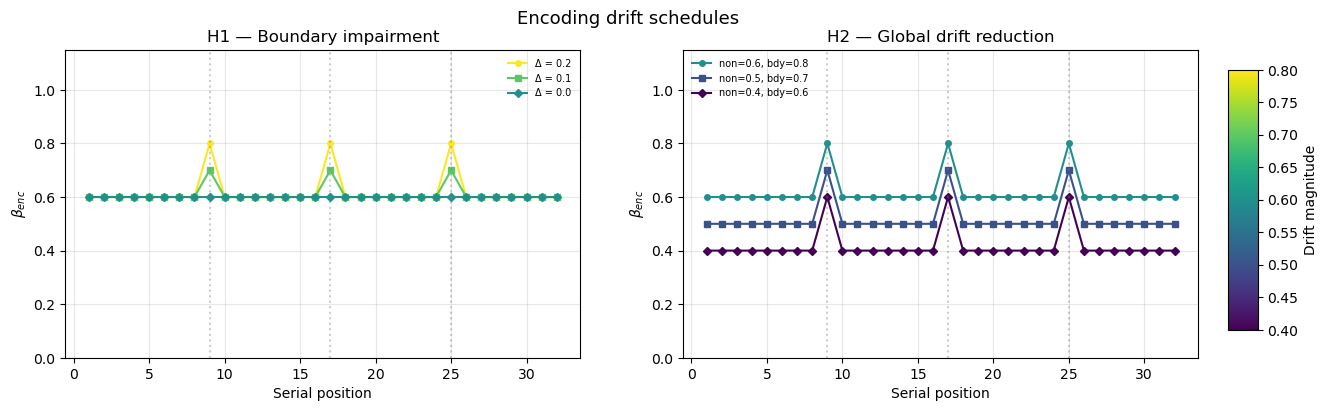

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
fig.subplots_adjust(right=0.88)

# H1
for label, B in h1_schedules.items():
    axs[0].plot(positions, B, marker=h1_markers[label],
                color=h1_colors[label], lw=1.5, ms=4, label=label)
for bp in bps:
    axs[0].axvline(bp, color='gray', ls=':', alpha=0.4)
axs[0].set_title('H1 — Boundary impairment')

# H2
for label, B in h2_schedules.items():
    axs[1].plot(positions, B, marker=h2_markers[label],
                color=h2_colors[label], lw=1.5, ms=4, label=label)
for bp in bps:
    axs[1].axvline(bp, color='gray', ls=':', alpha=0.4)
axs[1].set_title('H2 — Global drift reduction')

for ax in axs:
    ax.set_xlabel('Serial position')
    ax.set_ylabel(r'$\beta_{enc}$')
    ax.set_ylim(0, 1.15); ax.legend(frameon=False, fontsize=7)
    ax.grid(alpha=0.3)

# Shared colorbar
cax = fig.add_axes([0.90, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Drift magnitude')

fig.suptitle('Encoding drift schedules', fontsize=13)
plt.show()


---
# H1 — Boundary-Update Impairment

All non-boundary items have $\beta_{enc} = 0.6$.  Only the
boundary positions vary: $\beta_{bdy} = 0.6 + \Delta$.

A stronger boundary drift should make the context state change
more at that item, so the boundary item ends up associated with
a more different contextual vector than nearby items.  This
reduces episodic cueing across the boundary because items on the
two sides no longer share as similar a context.

**Primary readouts — three lag-1 transitions at each boundary:**

1. **(j−1) → j** — once the last old-context item is retrieved,
   does recall cross into the new context?  Cleanest
   "crossing-into" transition.

2. **j → (j−1)** — once the boundary item is retrieved, does
   recall transition back across the boundary?  Cleanest
   backward cross-boundary transition.

3. **j → (j+1)** — once the boundary item is retrieved, does
   recall continue within the new context?  If the boundary
   item becomes a stronger new-context anchor, this forward
   transition may *increase* even while cross-boundary
   retrieval decreases.

Transitions 2 and 3 are plotted together because both start
from the boundary item — they show where recall goes next
after retrieving that item.

**Additional readouts:** boundary-local SPC, recall accuracy.

**Secondary summary:** PFR.


## Run H1 simulations

In [4]:
h1_results = {}
for label, B in h1_schedules.items():
    print(f'  {label:12s} ...', end=' ')
    h1_results[label] = run_batch(B, n_sims=N_SIMS, seed=SEED, label=label)
    acc = recall_accuracy(h1_results[label]['recall_sims'], N)
    print(f'done  (accuracy = {acc:.3f})')

  Δ = 0.2      ... done  (accuracy = 0.164)
  Δ = 0.1      ... done  (accuracy = 0.163)
  Δ = 0.0      ... done  (accuracy = 0.164)


## H1 — Primary: boundary transitions

Three lag-1 transitions at each boundary, pooled across all
three boundary positions.

| Label | Transition | What it tests |
|---|---|---|
| pre→boundary | (j−1) → j | Crossing into new context |
| boundary→pre | j → (j−1) | Backward cross-boundary |
| boundary→post | j → (j+1) | Forward within new context |

Each is computed by `boundary_transition(rs, N, start_offset,
target_offset)`.  To check other lag magnitudes later, just
change the two offset numbers.

In [5]:
# ── Compute the three key transitions for every H1 condition ──
h1_pre_to_bdy = {}   # (j-1) -> j
h1_bdy_back   = {}   # j -> (j-1)
h1_bdy_fwd    = {}   # j -> (j+1)

for label, res in h1_results.items():
    rs = res['recall_sims']
    h1_pre_to_bdy[label] = boundary_transition(rs, N, -1,  0)
    h1_bdy_back[label]   = boundary_transition(rs, N,  0, -1)
    h1_bdy_fwd[label]    = boundary_transition(rs, N,  0,  1)

# Print a summary table
print(f"{'Condition':<14s}  {'(j-1)→j':>10s}  {'j→(j-1)':>10s}  {'j→(j+1)':>10s}")
print('-' * 50)
for label in h1_results:
    print(f"{label:<14s}  "
          f"{h1_pre_to_bdy[label]:10.4f}  "
          f"{h1_bdy_back[label]:10.4f}  "
          f"{h1_bdy_fwd[label]:10.4f}")

Condition          (j-1)→j     j→(j-1)     j→(j+1)
--------------------------------------------------
Δ = 0.2             0.1212      0.0367      0.1837
Δ = 0.1             0.0732      0.1075      0.2308
Δ = 0.0             0.1351      0.0714      0.1975


### Plot 1 — Pre-boundary to boundary: (j−1) → j

Does recall cross into the new context after retrieving the
last old-context item?  Higher Δ means a sharper context break,
so this transition should weaken.

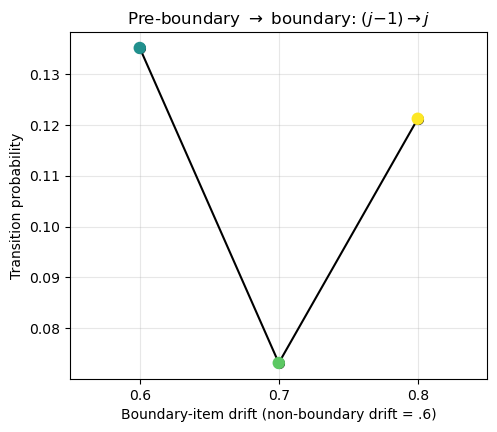

In [52]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(right=0.82)

y = [h1_pre_to_bdy[f'Δ = {d:.1f}'] for d in h1_deltas]
point_c = [cmap(DRIFT_NORM(v)) for v in h1_x_drift]

ax.plot(h1_x_drift, y, lw=1.5, color='black', marker='o', ms=7, zorder=2)
ax.scatter(h1_x_drift, y, c=point_c, s=80, edgecolor='none', zorder=3)

ax.set_xlabel(r'Boundary-item drift (non-boundary drift = .6)')
ax.set_ylabel('Transition probability')
ax.set_title(r'Pre-boundary $\to$ boundary: $(j{-}1) \to j$')
ax.set_xlim(0.55, 0.85)
ax.set_xticks([0.6, 0.7, 0.8])
ax.grid(alpha=0.3)

plt.show()


### Plot 2 — From the boundary item: j → (j−1) vs j → (j+1)

Both transitions start from the boundary item.  They show
where recall goes next after retrieving that item:

- **j → (j−1)** backward across the boundary (into old context)
- **j → (j+1)** forward within the new context

If a stronger Δ makes the boundary item a better anchor for
the new context, j → (j+1) may *increase* while j → (j−1)
decreases.

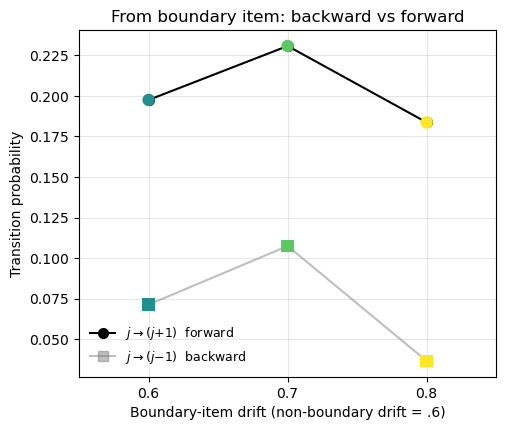

In [49]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(right=0.82)

y_back = [h1_bdy_back[f'Δ = {d:.1f}'] for d in h1_deltas]
y_fwd  = [h1_bdy_fwd[f'Δ = {d:.1f}']  for d in h1_deltas]
point_c = [cmap(DRIFT_NORM(v)) for v in h1_x_drift]

ax.plot(h1_x_drift, y_fwd,  lw=1.5, color='black', marker='o',
        ms=7, label=r'$j \to (j{+}1)$  forward', zorder=2)
ax.plot(h1_x_drift, y_back, lw=1.5, alpha=0.5,color='grey',  marker='s',
        ms=7, label=r'$j \to (j{-}1)$  backward', zorder=2)

ax.scatter(h1_x_drift, y_fwd,  c=point_c, s=80, edgecolor='none', zorder=3)
ax.scatter(h1_x_drift, y_back, c=point_c, s=80, marker='s', edgecolor='none', zorder=3)

ax.set_xlabel(r'Boundary-item drift (non-boundary drift = .6)')
ax.set_ylabel('Transition probability')
ax.set_title('From boundary item: backward vs forward')
ax.set_xlim(0.55, 0.85)
ax.set_xticks([0.6, 0.7, 0.8])
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.3)

plt.show()


### Boundary-local SPC

SPC in a local window around each boundary, averaged across
all three boundary positions.

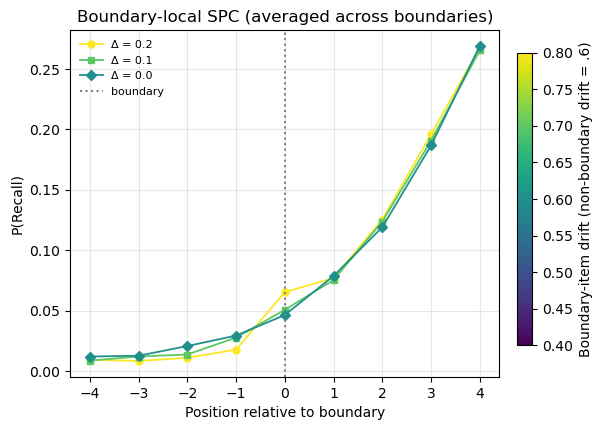

In [50]:
fig, ax = plt.subplots(figsize=(6, 4.5))

for label, res in h1_results.items():
    rel, mspc, se = boundary_local_spc(res['recall_sims'], N)
    c = cmap(DRIFT_NORM(h1_drift_mag[label]))
    ax.plot(rel, mspc, marker=h1_markers[label], color=c,
            lw=1.3, ms=5, label=label)

ax.axvline(0, color='gray', ls=':', label='boundary')
ax.set_xlabel('Position relative to boundary')
ax.set_ylabel('P(Recall)')
ax.set_title('Boundary-local SPC (averaged across boundaries)')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

fig.subplots_adjust(right=0.84)
cax = fig.add_axes([0.87, 0.18, 0.025, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Boundary-item drift (non-boundary drift = .6)')

plt.show()


### Recall accuracy

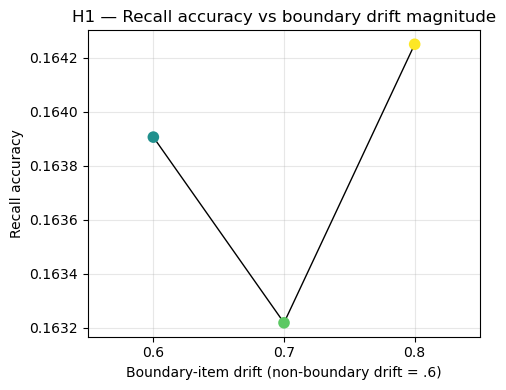

In [54]:
fig, ax = plt.subplots(figsize=(5, 4))
fig.subplots_adjust(right=0.82)

accs = [recall_accuracy(h1_results[f'Δ = {d:.1f}']['recall_sims'], N) for d in h1_deltas]
point_c = [cmap(DRIFT_NORM(v)) for v in h1_x_drift]

ax.plot(h1_x_drift, accs, lw=1, color='black')
ax.scatter(h1_x_drift, accs, c=point_c, s=70, edgecolor='none', zorder=3)

ax.set_xlabel(r'Boundary-item drift (non-boundary drift = .6)')
ax.set_ylabel('Recall accuracy')
ax.set_title('H1 — Recall accuracy vs boundary drift magnitude')
ax.set_xlim(0.55, 0.85)
ax.set_xticks([0.6, 0.7, 0.8])
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()


## H1 — Secondary summary: PFR

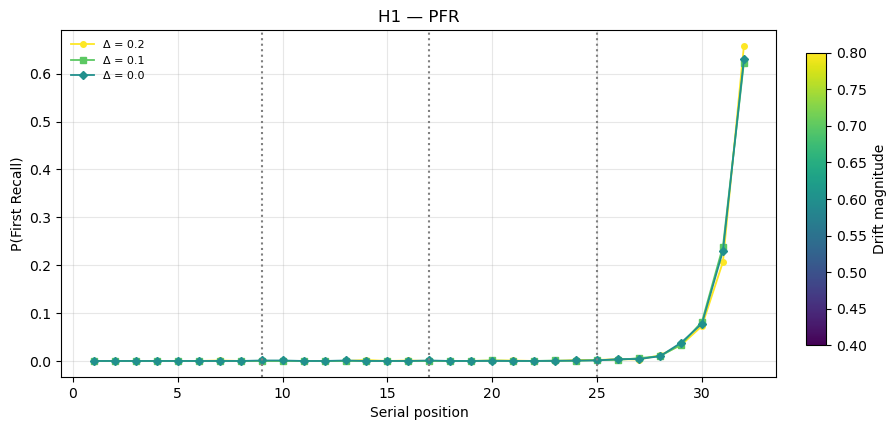

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))

for label, res in h1_results.items():
    pfr = compute_pfr(res['recall_sims'], N)
    c = cmap(DRIFT_NORM(h1_drift_mag[label]))
    ax.plot(positions, pfr, marker=h1_markers[label], color=c,
            lw=1.3, ms=4, label=label)

for bp in bps:
    ax.axvline(bp, color='gray', ls=':')

ax.set_xlabel('Serial position')
ax.set_ylabel('P(First Recall)')
ax.set_title('H1 — PFR')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

fig.subplots_adjust(right=0.84)
cax = fig.add_axes([0.87, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Boundary Drift (non-boundary drift = .6)')

plt.show()


## H1 — Compact panel

All primary + additional readouts in one figure.

- **Row 1:** the three boundary transitions, boundary-local SPC
- **Row 2:** recall accuracy, PFR

In [11]:
# H1 boundary-item drift values: B_j = B_nonboundary + Δ
# (Already defined in cell 5, but re-derived here for clarity)
h1_labels = [f'Δ = {d:.1f}' for d in h1_deltas]
h1_boundary_drifts = [B_NON + d for d in h1_deltas]

h1_drift_map = {f'Δ = {d:.1f}': B_NON + d for d in h1_deltas}

h1_cmap = mpl.cm.viridis
h1_norm_drift = DRIFT_NORM                     # unified 0.4–0.8
h1_point_colors = [h1_cmap(h1_norm_drift(v)) for v in h1_boundary_drifts]


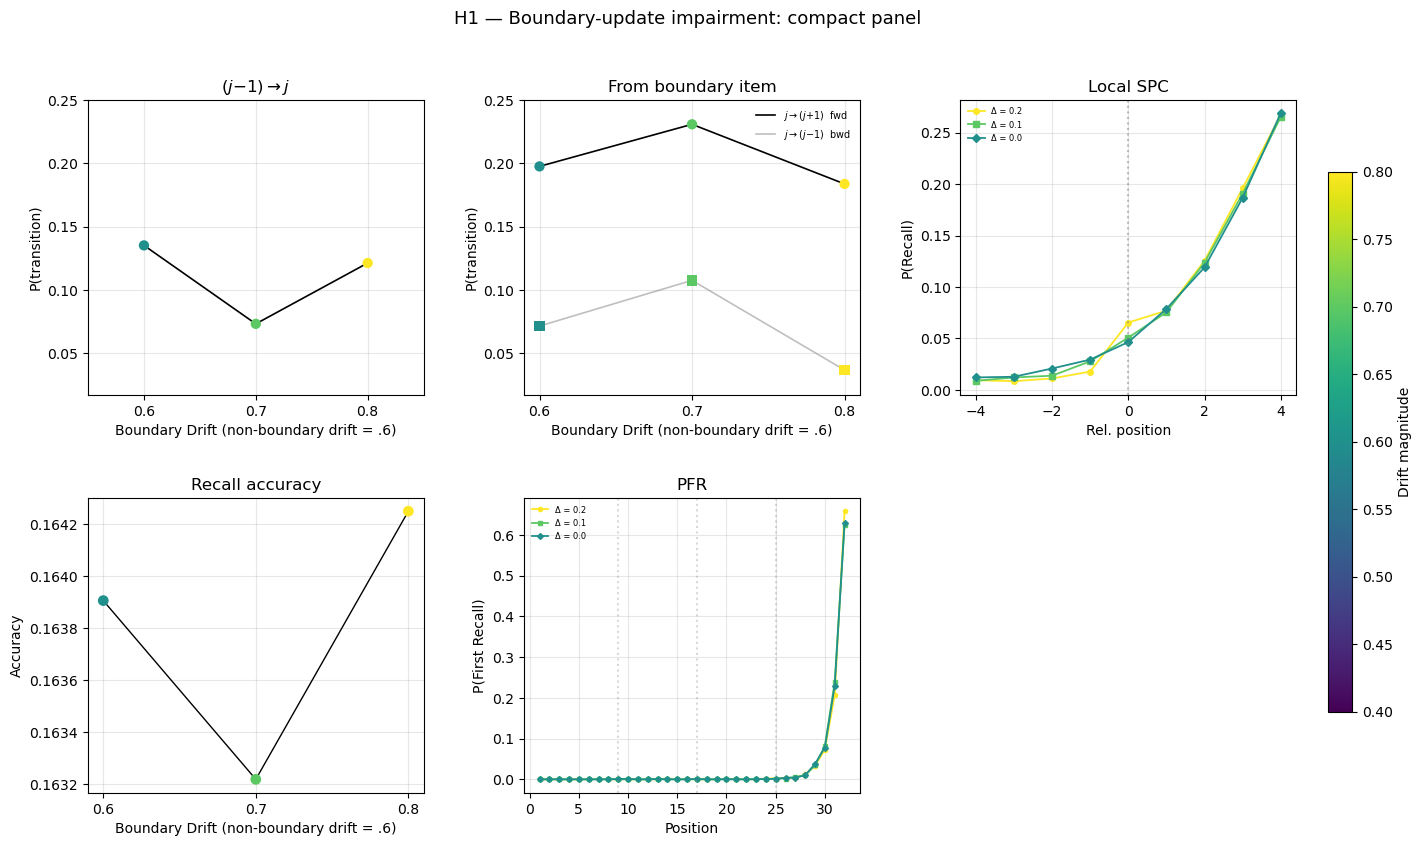

In [55]:
fig, axs = plt.subplots(2, 3, figsize=(16, 9))
fig.subplots_adjust(right=0.88, wspace=0.30, hspace=0.35)

# ── Row 0, col 0: (j-1) → j ──
y = [h1_pre_to_bdy[f'Δ = {d:.1f}'] for d in h1_deltas]
axs[0, 0].plot(h1_x_drift, y, lw=1.2, color='black')
axs[0, 0].scatter(h1_x_drift, y, c=h1_point_colors, s=55,
                   edgecolor='none', zorder=3)
axs[0, 0].set(xlabel=r'Boundary Drift (non-boundary drift = .6)', ylabel='P(transition)',
              title=r'$(j{-}1) \to j$')
axs[0, 0].set_xlim(0.55, 0.85)
axs[0, 0].set_xticks([0.6, 0.7, 0.8])

# ── Row 0, col 1: j → (j-1) and j → (j+1) ──
y_back = [h1_bdy_back[f'Δ = {d:.1f}'] for d in h1_deltas]
y_fwd  = [h1_bdy_fwd[f'Δ = {d:.1f}']  for d in h1_deltas]

axs[0, 1].plot(h1_x_drift, y_fwd,  lw=1.2, color='black',
               label=r'$j \to (j{+}1)$  fwd')
axs[0, 1].plot(h1_x_drift, y_back, lw=1.2, color='grey',alpha=0.5,
               label=r'$j \to (j{-}1)$  bwd')

axs[0, 1].scatter(h1_x_drift, y_fwd,  c=h1_point_colors, s=55,
                   marker='o', edgecolor='none', zorder=3)
axs[0, 1].scatter(h1_x_drift, y_back, c=h1_point_colors, s=55,
                   marker='s', edgecolor='none', zorder=3)

axs[0, 1].set(xlabel=r'Boundary Drift (non-boundary drift = .6)', ylabel='P(transition)',
              title='From boundary item')
axs[0, 0].set_xlim(0.55, 0.85)
axs[0, 1].set_xticks([0.6, 0.7, 0.8])
axs[0, 1].legend(frameon=False, fontsize=7)

# ── Row 0, col 2: boundary-local SPC ──
for label, res in h1_results.items():
    rel, mspc, se = boundary_local_spc(res['recall_sims'], N)
    c = h1_cmap(h1_norm_drift(h1_drift_map[label]))
    axs[0, 2].plot(rel, mspc, marker=h1_markers[label],
                   color=c, lw=1.3, ms=4, label=label)
axs[0, 2].axvline(0, color='gray', ls=':', alpha=0.5)
axs[0, 2].set(xlabel='Rel. position', ylabel='P(Recall)',
              title='Local SPC')
axs[0, 2].legend(frameon=False, fontsize=6)

# ── Sync y-axis for row 0, cols 0–1 (transition probabilities) ──
row0_trans_ymin = min(min(y), min(y_back), min(y_fwd))
row0_trans_ymax = max(max(y), max(y_back), max(y_fwd))
margin = (row0_trans_ymax - row0_trans_ymin) * 0.10
for c_idx in [0, 1]:
    axs[0, c_idx].set_ylim(row0_trans_ymin - margin,
                            row0_trans_ymax + margin)

# ── Row 1, col 0: recall accuracy ──
accs = [recall_accuracy(h1_results[f'Δ = {d:.1f}']['recall_sims'], N)
        for d in h1_deltas]
axs[1, 0].plot(h1_x_drift, accs, lw=1, color='black')
axs[1, 0].scatter(h1_x_drift, accs, c=h1_point_colors, s=60,
                  edgecolor='none', zorder=3)
axs[1, 0].set(xlabel=r'Boundary Drift (non-boundary drift = .6)', ylabel='Accuracy',
              title='Recall accuracy')
axs[0, 0].set_xlim(0.55, 0.85)
axs[1, 0].set_xticks([0.6, 0.7, 0.8])

# ── Row 1, col 1: PFR ──
for label, res in h1_results.items():
    pfr = compute_pfr(res['recall_sims'], N)
    c = h1_cmap(h1_norm_drift(h1_drift_map[label]))
    axs[1, 1].plot(positions, pfr, marker=h1_markers[label],
                   color=c, lw=1.3, ms=3, label=label)
for bp in bps:
    axs[1, 1].axvline(bp, color='gray', ls=':', alpha=0.3)
axs[1, 1].set(xlabel='Position', ylabel='P(First Recall)',
              title='PFR')
axs[1, 1].legend(frameon=False, fontsize=6)

# ── Row 1, col 2: blank / hide ──
axs[1, 2].axis('off')

for ax in axs.flat:
    if ax.axison:
        ax.grid(alpha=0.3)

# Colorbar: drift magnitude  0.4–0.8
cax = fig.add_axes([0.90, 0.20, 0.015, 0.60])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=h1_cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Drift magnitude')

fig.suptitle('H1 — Boundary-update impairment: compact panel', fontsize=13)
plt.show()


---
# H2 — Global Drift Reduction

All drift values are scaled down uniformly.  The relative
boundary salience is preserved.  This tests whether globally
reduced context integration produces a distinguishable pattern
from localized boundary impairment.

**Primary readouts:** whole-list SPC, lag-CRP, PFR, recall accuracy.

**Secondary readouts:** pooled boundary-local transition metrics
and boundary-local SPC (for comparison with H1).

## Run H2 simulations

In [13]:
h2_results = {}
for label, B in h2_schedules.items():
    print(f'  {label:22s} ...', end=' ')
    h2_results[label] = run_batch(B, n_sims=N_SIMS, seed=SEED, label=label)
    acc = recall_accuracy(h2_results[label]['recall_sims'], N)
    print(f'done  (accuracy = {acc:.3f})')

  non=0.6, bdy=0.8       ... done  (accuracy = 0.164)
  non=0.5, bdy=0.7       ... done  (accuracy = 0.216)
  non=0.4, bdy=0.6       ... done  (accuracy = 0.270)


## H2 — Primary metrics (whole-list)

### Serial Position Curve

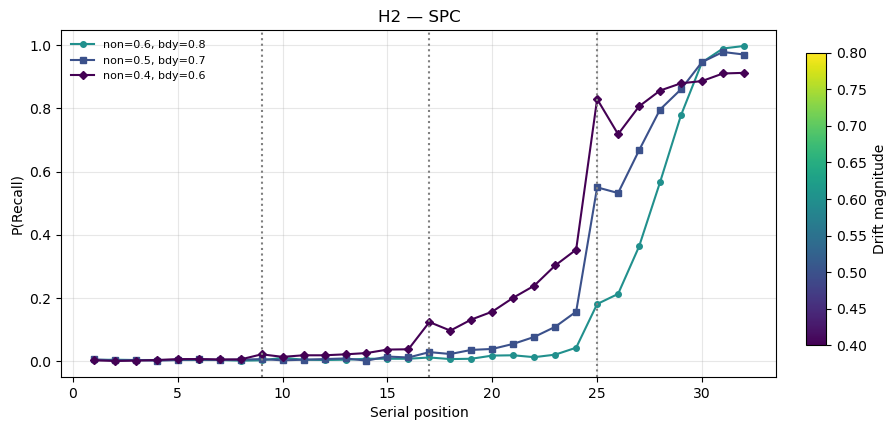

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.subplots_adjust(right=0.84)

for label, res in h2_results.items():
    spc = compute_spc(res['recall_sims'], N)
    ax.plot(positions, spc, marker=h2_markers[label],
            color=h2_colors[label], lw=1.5, ms=4, label=label)
for bp in bps:
    ax.axvline(bp, color='gray', ls=':')

ax.set_xlabel('Serial position'); ax.set_ylabel('P(Recall)')
ax.set_title('H2 — SPC')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

cax = fig.add_axes([0.87, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Drift magnitude')

plt.show()


### Lag-CRP

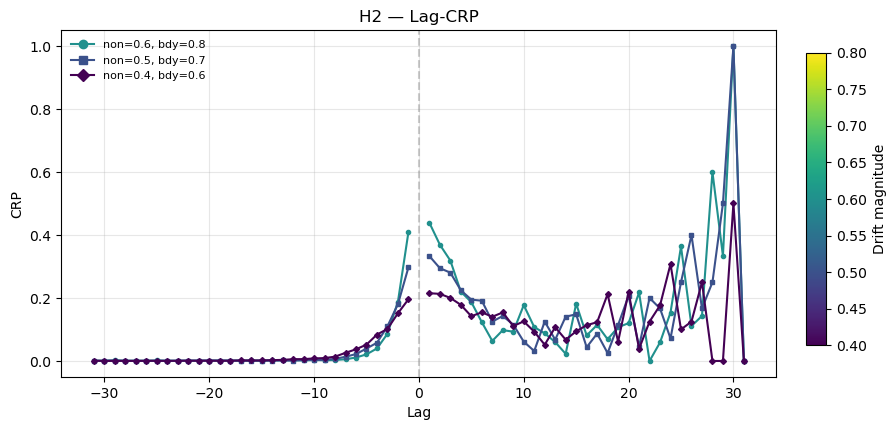

In [15]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.subplots_adjust(right=0.84)

for label, res in h2_results.items():
    lags, crp = compute_lag_crp(res['recall_sims'], N)
    for mask in [lags < 0, lags > 0]:
        ax.plot(lags[mask], crp[mask], marker=h2_markers[label],
                color=h2_colors[label], lw=1.5, ms=3)

ax.axvline(0, color='gray', ls='--', alpha=0.4)
ax.set_xlabel('Lag'); ax.set_ylabel('CRP')
ax.set_title('H2 — Lag-CRP')

handles = [plt.Line2D([],[], marker=h2_markers[l], color=h2_colors[l],
           lw=1.5, label=l) for l in h2_results]
ax.legend(handles=handles, frameon=False, fontsize=8)
ax.grid(alpha=0.3)

cax = fig.add_axes([0.87, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Drift magnitude')

plt.show()


### PFR

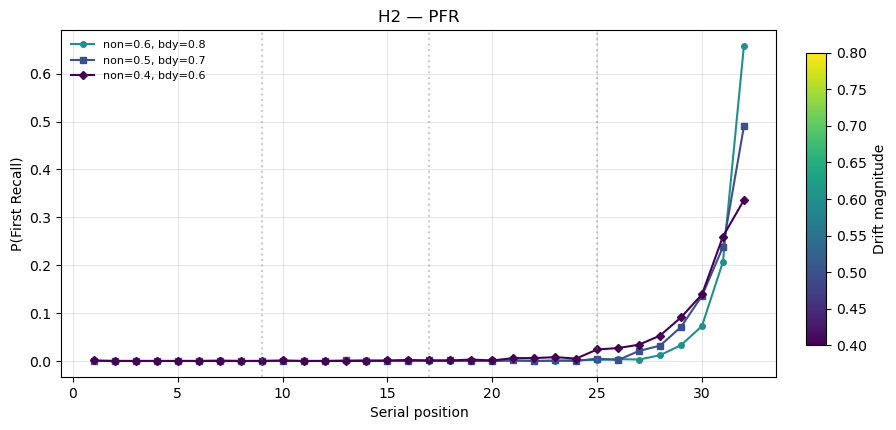

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.5))
fig.subplots_adjust(right=0.84)

for label, res in h2_results.items():
    pfr = compute_pfr(res['recall_sims'], N)
    ax.plot(positions, pfr, marker=h2_markers[label],
            color=h2_colors[label], lw=1.5, ms=4, label=label)
for bp in bps:
    ax.axvline(bp, color='gray', ls=':', alpha=0.4)

ax.set_xlabel('Serial position'); ax.set_ylabel('P(First Recall)')
ax.set_title('H2 — PFR')
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.3)

cax = fig.add_axes([0.87, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Drift magnitude')

plt.show()


### Recall accuracy

In [17]:
print(f"{'Condition':<25s}  {'Accuracy':>8s}")
print('-' * 37)
for label in h2_results:
    acc = recall_accuracy(h2_results[label]['recall_sims'], N)
    print(f'{label:<25s}  {acc:8.3f}')

Condition                  Accuracy
-------------------------------------
non=0.6, bdy=0.8              0.164
non=0.5, bdy=0.7              0.216
non=0.4, bdy=0.6              0.270


## H2 — Compact panel: whole-list metrics

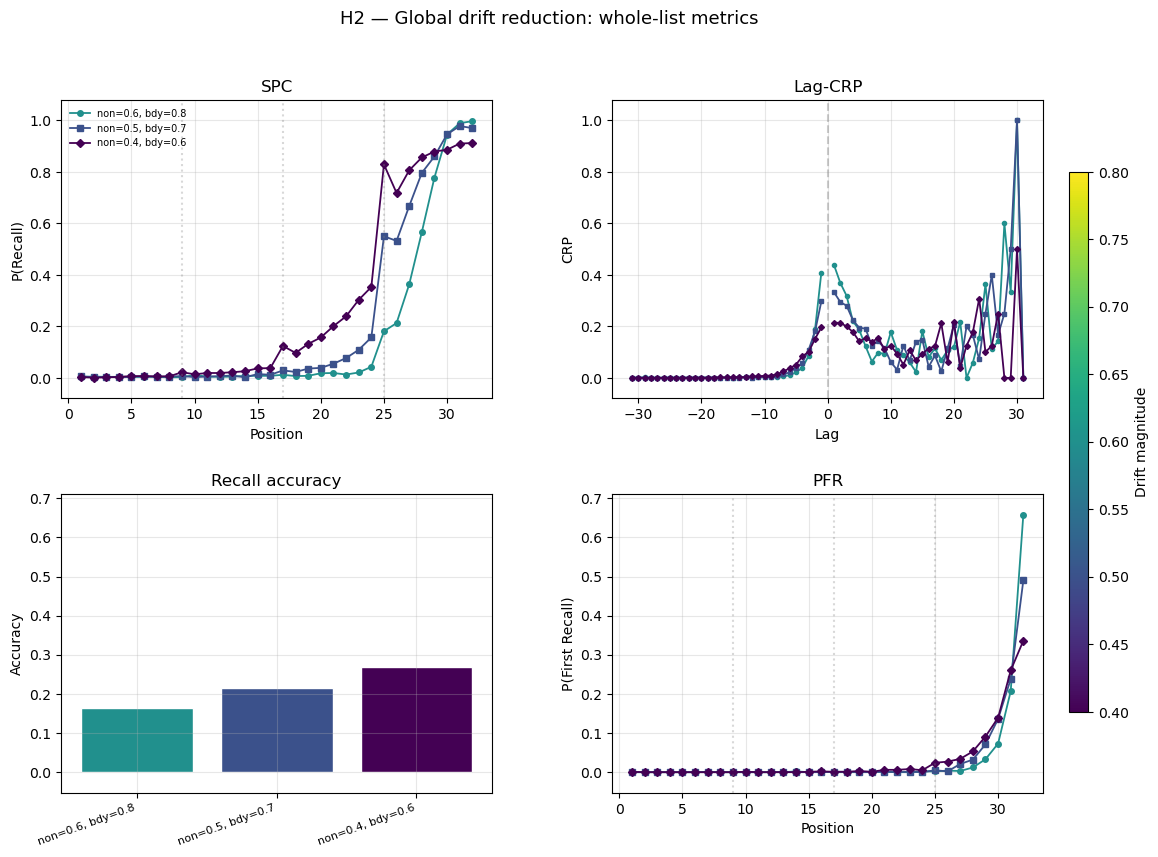

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.subplots_adjust(right=0.88, wspace=0.28, hspace=0.32)

# ── Collect data for y-axis synchronisation ──
spc_all, crp_all, pfr_all = [], [], []

for label, res in h2_results.items():
    c, mk = h2_colors[label], h2_markers[label]
    rs = res['recall_sims']

    spc_vals = compute_spc(rs, N)
    spc_all.extend(spc_vals)
    axs[0, 0].plot(
        positions, spc_vals,
        marker=mk, color=c, lw=1.3, ms=4, label=label
    )

    lags, crp = compute_lag_crp(rs, N)
    crp_all.extend(crp[~np.isnan(crp)])
    for m in [lags < 0, lags > 0]:
        axs[0, 1].plot(
            lags[m], crp[m],
            marker=mk, color=c, lw=1.3, ms=3
        )

    pfr_vals = compute_pfr(rs, N)
    pfr_all.extend(pfr_vals)
    axs[1, 1].plot(
        positions, pfr_vals,
        marker=mk, color=c, lw=1.3, ms=4
    )

# Accuracy bars
h2_labels = list(h2_results.keys())
h2_accs = [recall_accuracy(h2_results[l]['recall_sims'], N) for l in h2_labels]
axs[1, 0].bar(
    np.arange(len(h2_labels)),
    h2_accs,
    color=[h2_colors[l] for l in h2_labels],
    edgecolor='white'
)
axs[1, 0].set_xticks(np.arange(len(h2_labels)))
axs[1, 0].set_xticklabels(h2_labels, rotation=20, ha='right', fontsize=8)

for bp in bps:
    axs[0, 0].axvline(bp, color='gray', ls=':', alpha=0.3)
    axs[1, 1].axvline(bp, color='gray', ls=':', alpha=0.3)

axs[0, 0].set(xlabel='Position', ylabel='P(Recall)', title='SPC')
axs[0, 0].legend(frameon=False, fontsize=7)

axs[0, 1].axvline(0, color='gray', ls='--', alpha=0.4)
axs[0, 1].set(xlabel='Lag', ylabel='CRP', title='Lag-CRP')

axs[1, 0].set(ylabel='Accuracy', title='Recall accuracy')
axs[1, 1].set(xlabel='Position', ylabel='P(First Recall)', title='PFR')

# ── Sync y-axes within each row ──
# Row 0: SPC and Lag-CRP share P-scale
row0_ymin = min(min(spc_all), min(crp_all))
row0_ymax = max(max(spc_all), max(crp_all))
m0 = (row0_ymax - row0_ymin) * 0.08
for c_idx in [0, 1]:
    axs[0, c_idx].set_ylim(row0_ymin - m0, row0_ymax + m0)

# Row 1: Accuracy bar + PFR — sync where meaningful
# (accuracy and PFR have different semantics, but user wants same row scale)
row1_ymin = min(min(h2_accs), min(pfr_all))
row1_ymax = max(max(h2_accs), max(pfr_all))
m1 = (row1_ymax - row1_ymin) * 0.08
for c_idx in [0, 1]:
    axs[1, c_idx].set_ylim(row1_ymin - m1, row1_ymax + m1)

for ax in axs.flat:
    ax.grid(alpha=0.3)

# Colorbar
cax = fig.add_axes([0.90, 0.20, 0.015, 0.60])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Drift magnitude')

fig.suptitle('H2 — Global drift reduction: whole-list metrics', fontsize=13)
plt.show()


## H2 — Secondary: boundary transitions (for comparison with H1)

Same three transitions as H1, now computed for the global-drift
conditions.

In [19]:
# ── Compute boundary transitions for H2 ──
h2_pre_to_bdy = {}
h2_bdy_back   = {}
h2_bdy_fwd    = {}

for label, res in h2_results.items():
    rs = res['recall_sims']
    h2_pre_to_bdy[label] = boundary_transition(rs, N, -1,  0)
    h2_bdy_back[label]   = boundary_transition(rs, N,  0, -1)
    h2_bdy_fwd[label]    = boundary_transition(rs, N,  0,  1)

print(f"{'Condition':<25s}  {'(j-1)→j':>10s}  {'j→(j-1)':>10s}  {'j→(j+1)':>10s}")
print('-' * 60)
for label in h2_results:
    print(f"{label:<25s}  "
          f"{h2_pre_to_bdy[label]:10.4f}  "
          f"{h2_bdy_back[label]:10.4f}  "
          f"{h2_bdy_fwd[label]:10.4f}")

Condition                     (j-1)→j     j→(j-1)     j→(j+1)
------------------------------------------------------------
non=0.6, bdy=0.8               0.1212      0.0367      0.1837
non=0.5, bdy=0.7               0.3133      0.0924      0.2436
non=0.4, bdy=0.6               0.2026      0.0885      0.1643


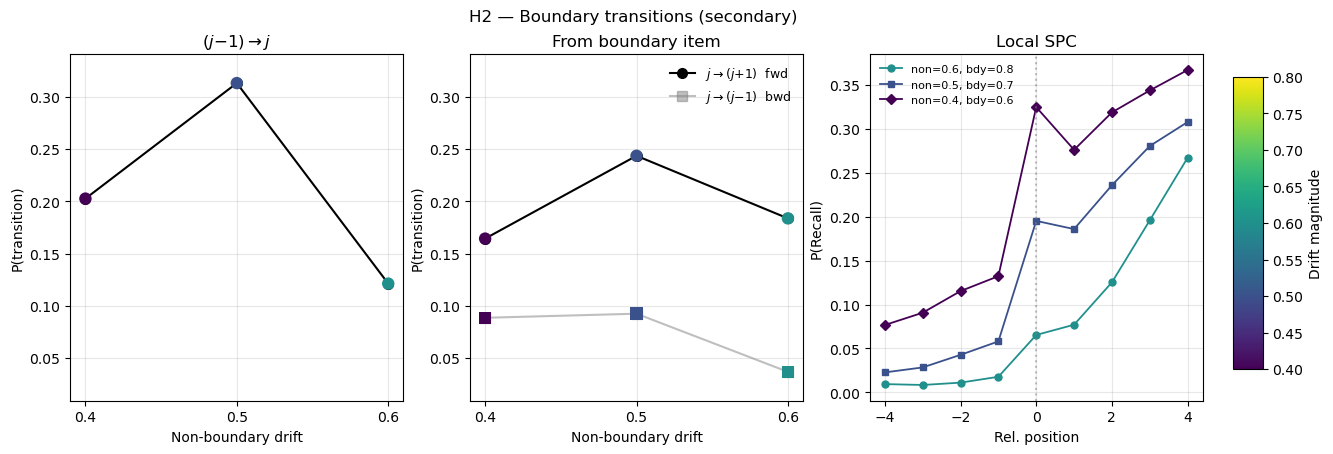

In [28]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
fig.subplots_adjust(right=0.88)

h2_x_vals = [p[0] for p in h2_params]
h2_point_c = [cmap(DRIFT_NORM(v)) for v in h2_x_vals]

# (j-1) → j  (single forward transition → black)
y = [h2_pre_to_bdy[l] for l in h2_results]
axs[0].plot(h2_x_vals, y, lw=1.5, color='black', marker='o', ms=7, zorder=2)
axs[0].scatter(h2_x_vals, y, c=h2_point_c, s=80, edgecolor='none', zorder=3)
axs[0].set(xlabel='Non-boundary drift', ylabel='P(transition)',
           title=r'$(j{-}1) \to j$')
axs[0].set_xticks(h2_x_vals)

# j → (j-1) and j → (j+1)
y_back = [h2_bdy_back[l] for l in h2_results]
y_fwd  = [h2_bdy_fwd[l]  for l in h2_results]
axs[1].plot(h2_x_vals, y_fwd,  lw=1.5, color='black', marker='o',
            ms=7, label=r'$j \to (j{+}1)$  fwd', zorder=2)
axs[1].plot(h2_x_vals, y_back, lw=1.5, color='grey',  alpha=0.5,marker='s',
            ms=7, label=r'$j \to (j{-}1)$  bwd', zorder=2)
axs[1].scatter(h2_x_vals, y_fwd,  c=h2_point_c, s=80, edgecolor='none', zorder=3)
axs[1].scatter(h2_x_vals, y_back, c=h2_point_c, s=80, marker='s',
               edgecolor='none', zorder=3)
axs[1].set(xlabel='Non-boundary drift', ylabel='P(transition)',
           title='From boundary item')
axs[1].set_xticks(h2_x_vals)
axs[1].legend(frameon=False, fontsize=9)

# Sync y for first two panels (both are transition probs)
t_ymin = min(min(y), min(y_back), min(y_fwd))
t_ymax = max(max(y), max(y_back), max(y_fwd))
tm = (t_ymax - t_ymin) * 0.10
axs[0].set_ylim(t_ymin - tm, t_ymax + tm)
axs[1].set_ylim(t_ymin - tm, t_ymax + tm)

# Boundary-local SPC
for label, res in h2_results.items():
    rel, mspc, se = boundary_local_spc(res['recall_sims'], N)
    axs[2].plot(rel, mspc, marker=h2_markers[label],
               color=h2_colors[label], lw=1.3, ms=5, label=label)
axs[2].axvline(0, color='gray', ls=':', alpha=0.5)
axs[2].set(xlabel='Rel. position', ylabel='P(Recall)',
           title='Local SPC')
axs[2].legend(frameon=False, fontsize=8)

for ax in axs:
    ax.grid(alpha=0.3)

cax = fig.add_axes([0.90, 0.18, 0.02, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax).set_label('Drift magnitude')

fig.suptitle('H2 — Boundary transitions (secondary)', fontsize=12)
plt.show()


---
# H1 vs H2 Boundary-Local Comparison

Question: do localized boundary impairment (H1) and
global drift reduction (H2) leave distinguishable fingerprints
at the boundary?

Top row = H1 (x-axis = $\Delta$); bottom row = H2 (x-axis =
non-boundary drift).  Columns show the three boundary
transitions and boundary-local SPC.

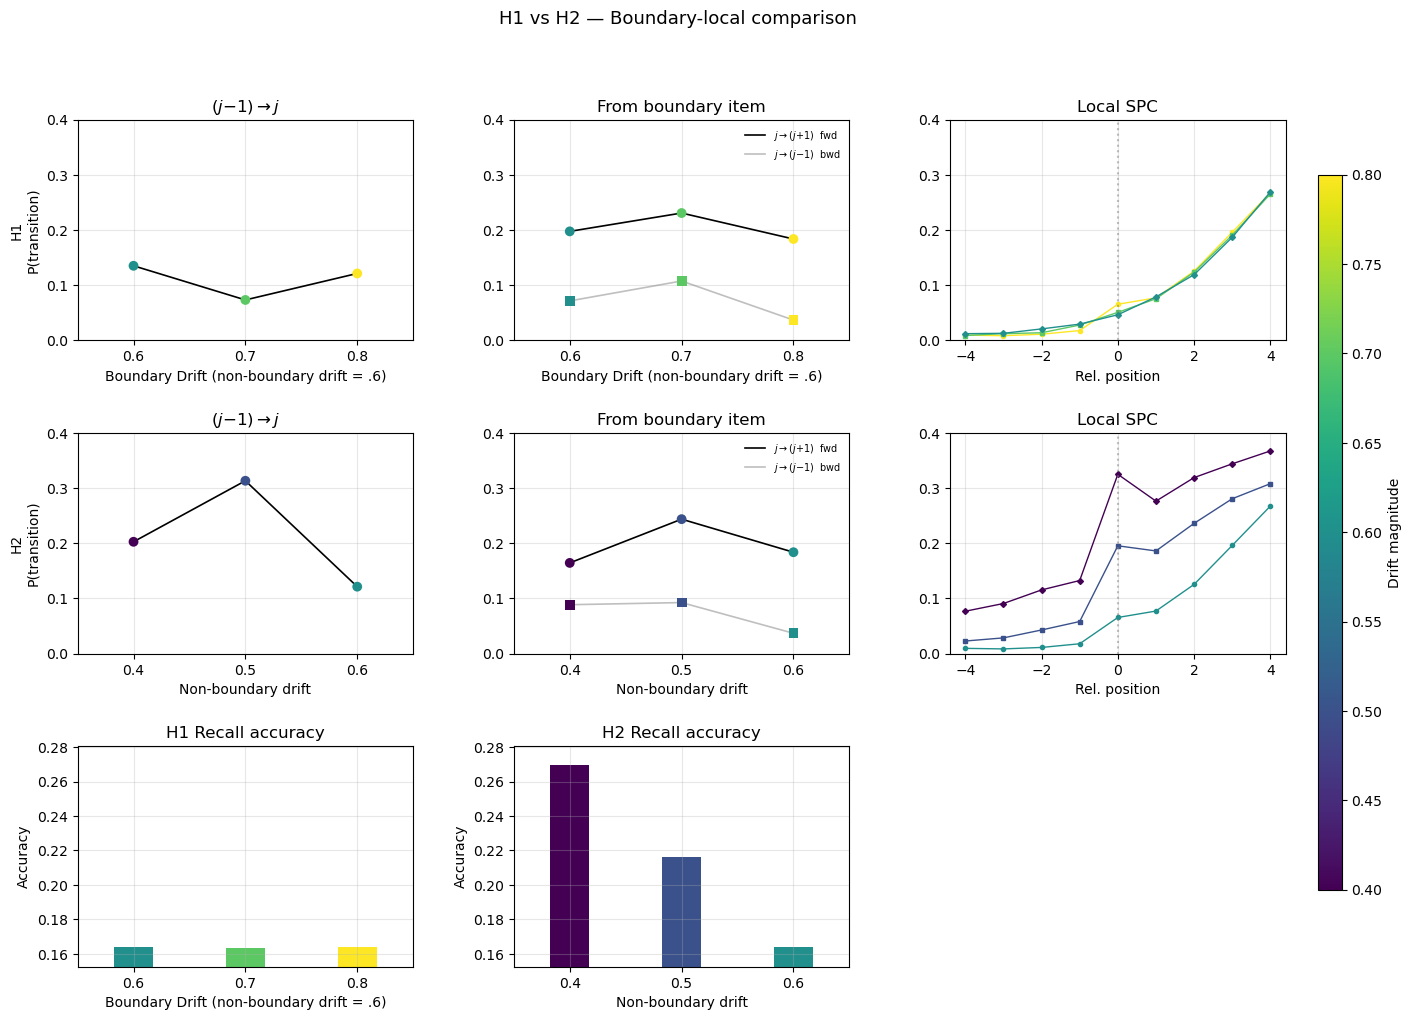

In [58]:
fig, axs = plt.subplots(3, 3, figsize=(16, 11))
fig.subplots_adjust(right=0.88, wspace=0.30, hspace=0.42)

# ── Row 0: H1 ──
y_h1_pre = [h1_pre_to_bdy[f'Δ = {d:.1f}'] for d in h1_deltas]
h1_pc = [cmap(DRIFT_NORM(v)) for v in h1_x_drift]

axs[0, 0].plot(h1_x_drift, y_h1_pre, lw=1.2, color='black', zorder=2)
axs[0, 0].scatter(h1_x_drift, y_h1_pre, c=h1_pc, s=50,
                  edgecolor='none', zorder=3)
axs[0, 0].set(xlabel=r'Boundary Drift (non-boundary drift = .6)',
              title=r'$(j{-}1) \to j$')
axs[0, 0].set_xlim(0.55, 0.85)
axs[0, 0].set_xticks([0.6, 0.7, 0.8])

y_h1_back = [h1_bdy_back[f'Δ = {d:.1f}'] for d in h1_deltas]
y_h1_fwd  = [h1_bdy_fwd[f'Δ = {d:.1f}']  for d in h1_deltas]
axs[0, 1].plot(h1_x_drift, y_h1_fwd, lw=1.2, color='black',
               label=r'$j \to (j{+}1)$  fwd', zorder=2)
axs[0, 1].plot(h1_x_drift, y_h1_back, lw=1.2, color='grey', alpha=0.5,
               label=r'$j \to (j{-}1)$  bwd', zorder=2)
axs[0, 1].scatter(h1_x_drift, y_h1_fwd, c=h1_pc, s=50,
                  edgecolor='none', zorder=3)
axs[0, 1].scatter(h1_x_drift, y_h1_back, c=h1_pc, s=50,
                  marker='s', edgecolor='none', zorder=3)
axs[0, 1].set(xlabel=r'Boundary Drift (non-boundary drift = .6)',
              title='From boundary item')
axs[0, 1].set_xlim(0.55, 0.85)
axs[0, 1].set_xticks([0.6, 0.7, 0.8])
axs[0, 1].legend(frameon=False, fontsize=7)

for label, res in h1_results.items():
    rel, mspc, se = boundary_local_spc(res['recall_sims'], N)
    c = cmap(DRIFT_NORM(h1_drift_mag[label]))
    axs[0, 2].plot(rel, mspc, marker=h1_markers[label],
                   color=c, lw=1, ms=3)
axs[0, 2].axvline(0, color='gray', ls=':', alpha=0.5)
axs[0, 2].set(xlabel='Rel. position', title='Local SPC')

# ── Row 1: H2 ──
h2_x = [p[0] for p in h2_params]
h2_pc = [cmap(DRIFT_NORM(v)) for v in h2_x]

y_h2_pre = [h2_pre_to_bdy[l] for l in h2_results]
axs[1, 0].plot(h2_x, y_h2_pre, lw=1.2, color='black', zorder=2)
axs[1, 0].scatter(h2_x, y_h2_pre, c=h2_pc, s=50,
                  edgecolor='none', zorder=3)
axs[1, 0].set(xlabel='Non-boundary drift',
              title=r'$(j{-}1) \to j$')
axs[1, 0].set_xlim(0.35, 0.65)
axs[1, 0].set_xticks([0.4, 0.5, 0.6])

y_h2_back = [h2_bdy_back[l] for l in h2_results]
y_h2_fwd  = [h2_bdy_fwd[l]  for l in h2_results]
axs[1, 1].plot(h2_x, y_h2_fwd, lw=1.2, color='black',
               label=r'$j \to (j{+}1)$  fwd', zorder=2)
axs[1, 1].plot(h2_x, y_h2_back, lw=1.2, color='grey', alpha=0.5,
               label=r'$j \to (j{-}1)$  bwd', zorder=2)
axs[1, 1].scatter(h2_x, y_h2_fwd, c=h2_pc, s=50,
                  edgecolor='none', zorder=3)
axs[1, 1].scatter(h2_x, y_h2_back, c=h2_pc, s=50,
                  marker='s', edgecolor='none', zorder=3)
axs[1, 1].set(xlabel='Non-boundary drift',
              title='From boundary item')
axs[1, 1].set_xlim(0.35, 0.65)
axs[1, 1].set_xticks([0.4, 0.5, 0.6])
axs[1, 1].legend(frameon=False, fontsize=7)

for label, res in h2_results.items():
    rel, mspc, se = boundary_local_spc(res['recall_sims'], N)
    c = cmap(DRIFT_NORM(h2_drift_mag[label]))
    axs[1, 2].plot(rel, mspc, marker=h2_markers[label],
                   color=c, lw=1, ms=3)
axs[1, 2].axvline(0, color='gray', ls=':', alpha=0.5)
axs[1, 2].set(xlabel='Rel. position', title='Local SPC')

# ── Row 2: Recall accuracy bars ──
# H1
h1_accs = [recall_accuracy(h1_results[f'Δ = {d:.1f}']['recall_sims'], N)
           for d in h1_deltas]
axs[2, 0].bar(h1_x_drift, h1_accs, width=0.035, color=h1_pc, edgecolor='none')
axs[2, 0].set(xlabel=r'Boundary Drift (non-boundary drift = .6)',
              ylabel='Accuracy',
              title='H1 Recall accuracy')
axs[2, 0].set_xlim(0.55, 0.85)
axs[2, 0].set_xticks([0.6, 0.7, 0.8])

# H2
h2_labels = list(h2_results.keys())
h2_accs = [recall_accuracy(h2_results[l]['recall_sims'], N) for l in h2_labels]
axs[2, 1].bar(h2_x, h2_accs, width=0.035, color=h2_pc, edgecolor='none')
axs[2, 1].set(xlabel='Non-boundary drift',
              ylabel='Accuracy',
              title='H2 Recall accuracy')
axs[2, 1].set_xlim(0.35, 0.65)
axs[2, 1].set_xticks([0.4, 0.5, 0.6])

# Blank panel
axs[2, 2].axis('off')

# ── Force y-ranges ──
for r in [0, 1]:
    for c in range(3):
        axs[r, c].set_ylim(0.0, 0.40)

# Accuracy row can have its own scale
acc_min = min(h1_accs + h2_accs)
acc_max = max(h1_accs + h2_accs)
pad = max(0.005, 0.1 * (acc_max - acc_min))
axs[2, 0].set_ylim(max(0, acc_min - pad), acc_max + pad)
axs[2, 1].set_ylim(max(0, acc_min - pad), acc_max + pad)

# Labels and grid
for i, lbl in enumerate(['H1', 'H2']):
    axs[i, 0].set_ylabel(f'{lbl}\nP(transition)')
    for ax in axs[i]:
        ax.grid(alpha=0.3)

axs[2, 0].grid(alpha=0.3)
axs[2, 1].grid(alpha=0.3)

# Colorbar
cax = fig.add_axes([0.90, 0.18, 0.015, 0.65])
sm = mpl.cm.ScalarMappable(norm=DRIFT_NORM, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label('Drift magnitude')

fig.suptitle('H1 vs H2 — Boundary-local comparison', fontsize=13)
plt.show()


---
## Interpretation guide

If **H1** and **H2** produce *distinguishable* fingerprints, we
expect to see:

- **H1 (boundary impairment)**: as $\Delta$ increases, the
  context break at the boundary sharpens.  $(j{-}1) \to j$
  and $j \to (j{-}1)$ should decrease (harder to cross), while
  $j \to (j{+}1)$ may increase (boundary item becomes a
  stronger anchor for the new context).  Whole-list accuracy
  and SPC shape away from the boundary should show minimal
  change.

- **H2 (global reduction)**: proportional decline across *all*
  positions in SPC and lag-CRP, with the boundary transitions
  declining in step with the global trend (not
  disproportionately).  The $j \to (j{+}1)$ vs $j \to (j{-}1)$
  divergence should be weaker or absent.

The comparison panel should reveal whether the boundary-specific
metrics drop **faster** under H1 than H2 (selective
vulnerability), or whether both hypotheses produce parallel
declines (no dissociation).

### Metric hierarchy

| Hypothesis | Primary | Additional | Secondary |
|---|---|---|---|
| **H1 — Boundary impairment** | (j−1)→j, j→(j−1), j→(j+1) | boundary-local SPC, recall accuracy | PFR |
| **H2 — Global drift reduction** | whole-list SPC, lag-CRP, PFR, recall accuracy | (j−1)→j, j→(j−1), j→(j+1), boundary-local SPC | — |

### Scalability

To check longer-range transitions, call `boundary_transition`
with different offsets — no new helper functions needed:

```python
# lag-2
boundary_transition(rs, N, -2,  0)   # (j-2) → j
boundary_transition(rs, N,  0, -2)   # j → (j-2)
boundary_transition(rs, N,  0,  2)   # j → (j+2)

# lag-3
boundary_transition(rs, N, -3,  0)   # (j-3) → j
boundary_transition(rs, N,  0, -3)   # j → (j-3)
boundary_transition(rs, N,  0,  3)   # j → (j+3)
```